# Revisions- Figure 3-7 + Supplementary Figure 1+2 Code
Contains code to produce figures present in Fig 3-7. 

*Run Order*:
- Environment and Imports
- Config (paths, parameters)
- Load Data
- Process Data
- Cross condition decoding generalization (CCG) figures:
    - Figure 3: B
    - Figure 4: B
- CCG Class predictions:
    - Figure 3: C
    - Figure 4: C, F
- Linear SVM accuracy figures:
    - Figure 5: C, D
    - Figure 6: C, D
    - Figure 7: C, G
    - Supplementary Figure 2: F, H
- Save Figures and Tables

## Setup


#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

#custom function import
from preprocess_data import hyper_param_dict, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.8.4 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

#### Extract pre-built time-series and transform


In [3]:
def get_matrix_of_run_record(latest_runs: pd.DataFrame,
                              decoding_type_to_var: dict,
                                col_to_extract: str = 'weight_file_saved'):
    ''' read in the latest runs of decoding and return a dictionary of dataframes for each decoding type 
    inputs:
    latest_run: dataframe of latest runs with columns including 'decoding_type' and e.g. activity matrix or cell weights
    decoding_type_to_var: dict mapping decoding_type strings to variable names for the output dictionary '''

    # read parquets into a dictionary
    run_record_df = {}
    for _, row in latest_runs.iterrows():
        decoding_type = row['decoding_type']
        extracted_filepath = row[col_to_extract]
        print(f"extracted filepath in {col_to_extract}: {extracted_filepath}")
        if decoding_type in decoding_type_to_var:
            var_name = decoding_type_to_var[decoding_type]
            run_record_df[var_name] = pd.read_parquet(extracted_filepath)
            run_record_df[var_name]['run_end_time'] = row['run_end_time']
            run_record_df[var_name]['run_source_dataset'] = row['run_dataset_used']
            run_record_df[var_name]['run_end_date'] = run_record_df[var_name]['run_end_time'].astype(str).str.split(" ").str[0]
            run_record_df[var_name]['dataset_label'] = ("Old Paper Ensembles" if r"\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet" in row['run_dataset_used'] else "New Ensembles")
            print(f"Loaded {decoding_type} from {row['run_end_time']} ({len(run_record_df[var_name])} rows) -> {var_name}")
        else:
            print(f"Warning: Unknown decoding type '{decoding_type}', skipped")
    return run_record_df

def parse_decoder_key(df, stage_names, geno_order, decoder_key_col='decoder_key'):
    """
    Parse decoder_key column to extract bootstrap_run, ensemble, geno_day, k_fold, train_on, and test_on.
    
    Parameters----------
    df : pd.DataFrame containing the decoder_key column
    stage_names : list of stage/ensemble names to match (e.g., ['early', 'late'])
    geno_order : list of genotype-day values to match (e.g., ['HET_D1', 'WT_D1'])
    decoder_key_col : str, optional
        Name of the decoder key column (default: 'decoder_key')

    Returns-------
    pd.DataFrame with added columns: bootstrap_run, ensemble, geno_day, k_fold, train_test_info, train_on, test_on
    """
    result = df.copy()
    key_col = result[decoder_key_col]
    
    result['bootstrap_run'] = key_col.str.split('_').str[0].astype(int)
    result['ensemble'] = key_col.str.extract(f"({'|'.join(stage_names)})")
    result['geno_day'] = key_col.str.extract(f"({'|'.join(geno_order)})")
    result['k_fold'] = key_col.str.split('_').str[-1].astype(int)
    
    result['train_test_info'] = result.apply(
        lambda r: r[decoder_key_col].split(r['geno_day'] + '_', 1)[-1], axis=1)
    result['train_on'] = result['train_test_info'].str.split('_to_').str[0]
    result['test_on'] = result['train_test_info'].str.split('_to_').str[1].str[:-2]
    
    return result

In [4]:
#declare loc/names of files to read
trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file 
# trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)


In [5]:
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'
## 
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
subject_stage_info_df.sample()

,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
174,7_6_HET_RS2,Het CLNZ,Early_IA_Error,"[7_6_HET_RS2-10, 7_6_HET_RS2-20, 7_6_HET_RS2-2...",12,107,"[2, 3, 5]",3,"[False, False, False]"


In [6]:
trial_tseries_df_norm.columns

Index(['task_phase_vec', 'IA_RS_vec', 'corr_err_vec', 'trial_num', 'neuron_ID',
       'section', 'subject_name', 'session', 'raw_ID', 'day',
       ...
       'pvalue_post_outcome_Late_RS', 'Run_end_time', 'num_shuffles',
       'any_enrichment', 'enriched_in_phase', 'normalized',
       'max_trial_val_all_time', 'min_max_type', 'mean_rate_in_trial',
       'cell_is_active_in_trial'],
      dtype='object', length=105)

#### Centralize import of all time-series

In [7]:
import re

def parse_run_datetime(row):
    end = str(row['run_end_time']).strip()
    if re.match(r'\d{4}-', end):
        return pd.to_datetime(end, errors='coerce')
    match = re.match(r'^(\d+):(\d+\.?\d*)$', end)
    if match:
        date = pd.to_datetime(row['run_date'], format='%d_%b_%Y')
        return date + pd.Timedelta(minutes=int(match.group(1)), seconds=float(match.group(2)))
    return pd.NaT

In [8]:
# Map decoding types to their target variable names
decoding_type_to_var = {
    'in_distribution': 'decode_scores',
    'timebin_decoding': 'time_decode_scores',
    'out_of_distribution': 'decode_out_distrib',
    'out_of_distribution_label_permuted': 'decode_out_distrib_label_permuted',
    'out_of_distribution_whole_pop': 'decode_out_distrib_whole_pop',
    'out_of_distribution_whole_pop_permuted': 'decode_out_distrib_whole_pop_permuted',
    'out_of_distribution_activity_match': 'decode_CCG_activity_match'
}
## choose run record to draw 
run_record_loc = r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026'
# run_record_loc = r'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_24_Jan_2026'

use_dff = False
if use_dff:
    dff_loc = r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_dff_07_Mar_2026'
    run_record_loc = dff_loc   
# r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_12_Feb_2026'
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
last_run_info = pd.read_csv(run_record_loc + '/' + generalize_svm_record_file)
last_run_info

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved,data_type
0,0,15_Feb_2026,in_distribution,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN
1,1,15_Feb_2026,out_of_distribution_whole_pop,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN
2,2,15_Feb_2026,out_of_distribution_label_permuted,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN
3,3,15_Feb_2026,timebin_decoding,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,NaN
4,4,16_Feb_2026,out_of_distribution,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN
5,5,16_Feb_2026,out_of_distribution_whole_pop,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,NaN
6,6,04_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-04 14:51:43.921476,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,NaN
7,7,22_Mar_2026,out_of_distribution_whole_pop,2026-03-22 14:59:14.852618,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,1000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,post_outcome_activity
8,8,22_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-22 14:59:14.852618,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,1000.0,NaN,NaN,post_outcome_activity


In [9]:
last_run_info['run_datetime'] = last_run_info.apply(parse_run_datetime, axis=1)
latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_datetime'].idxmax()]
print(f"run_dataset_used in loaded runs: {latest_runs['run_dataset_used'].unique()}")
latest_runs

run_dataset_used in loaded runs: ['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab_import_10000_shuff_minmax_normed_trial_tseries_31-Jan-2026\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet'
 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet']


,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved,data_type,run_datetime
0,0,15_Feb_2026,in_distribution,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN,2026-02-15 00:13:30.600000
4,4,16_Feb_2026,out_of_distribution,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN,2026-02-16 00:49:14.400000
2,2,15_Feb_2026,out_of_distribution_label_permuted,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,NaN,2026-02-15 00:13:30.600000
7,7,22_Mar_2026,out_of_distribution_whole_pop,2026-03-22 14:59:14.852618,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,1000.0,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,post_outcome_activity,2026-03-22 14:59:14.852618
8,8,22_Mar_2026,out_of_distribution_whole_pop_permuted,2026-03-22 14:59:14.852618,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,1000.0,NaN,NaN,post_outcome_activity,2026-03-22 14:59:14.852618
3,3,15_Feb_2026,timebin_decoding,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10.0,10000.0,NaN,NaN,NaN,2026-02-15 00:13:30.600000


In [10]:
decode_dfs = get_matrix_of_run_record(latest_runs, decoding_type_to_var, col_to_extract= 'run_output_filename')
print(f"\n Dataframes loaded for decoding types: {list(decode_dfs.keys())}")


extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode enrich_unit 10000 pseudopop post_outcome_activity 15_Feb_2026.parquet
Loaded in_distribution from 13:30.6 (9600000 rows) -> decode_scores
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode (Out of Distrib) 10000 pseudopop post_outcome_activity 16_Feb_2026.parquet
Loaded out_of_distribution from 49:14.4 (1200000 rows) -> decode_out_distrib
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026\Decode (LABEL PERMUTE- Out of Distrib) 10000 pseudopop post_outcome_activity 15_Feb_2026.parquet
Loaded out_of_distribution_label_permuted from 13:30.6 (1200000 rows) -> decode_out

In [11]:
# Unpack to standalone variables for convenience
decode_scores = decode_dfs.get('decode_scores')
time_decode_scores = decode_dfs.get('time_decode_scores')
decode_out_distrib = decode_dfs.get('decode_out_distrib')
print(f"Loaded: {list(decode_dfs.keys())}")

Loaded: ['decode_scores', 'decode_out_distrib', 'decode_out_distrib_label_permuted', 'decode_out_distrib_whole_pop', 'decode_out_distrib_whole_pop_permuted', 'time_decode_scores']


In [12]:

decode_out_distrib

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label
0,0.674805,79.0,79.00,0.464063,0.210625,0.289375,0.035938,0.0,0.615234,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
1,0.694824,79.0,61.75,0.423125,0.271875,0.228125,0.076875,0.0,0.489990,0.663086,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
2,0.555176,79.0,79.00,0.306875,0.248438,0.251562,0.193125,0.0,0.663086,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
3,0.561035,79.0,55.00,0.290625,0.270313,0.229687,0.209375,0.0,0.681641,0.615234,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
4,0.509277,28.0,28.00,0.262188,0.247187,0.252812,0.237812,0.0,0.621094,0.787109,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,0.533203,19.0,13.00,0.346250,0.186875,0.313125,0.153750,0.0,0.638184,0.675781,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119996,0.557617,9.0,3.00,0.057500,0.500000,0.000000,0.442500,0.0,0.000000,0.227905,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119997,0.566406,9.0,5.00,0.081250,0.485000,0.015000,0.418750,0.0,0.000000,0.227905,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles
119998,0.500000,9.0,3.00,0.000000,0.500000,0.000000,0.500000,0.0,0.227905,0.000000,...,0.75,4,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles


In [13]:
# #### read location of decoding csv from readout
# decoding_filename = "Decode enrich_unit 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_scores = pd.read_parquet(data_location / decoding_filename)
# #
# time_decoding_filename = "Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet"
# time_decode_scores = pd.read_parquet(data_location / time_decoding_filename)

# CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_out_distrib = pd.read_parquet(data_location / CCG_filename)

#### Load and extract decoding CSV


In [14]:

pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])['accuracy'].mean().reset_index() 
pop_mean_decoding[['class_0', 'class_1']]= pop_mean_decoding['classes decoded'].str.split('_v_',expand=True)
print(pop_mean_decoding.info())
pop_mean_decoding.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 7 columns):
 #   Column             Dtype   
---  ------             -----   
 0   geno_day           category
 1   enriched_group     category
 2   classes decoded    category
 3   pseudopop_run_num  int32   
 4   accuracy           float32 
 5   class_0            object  
 6   class_1            object  
dtypes: category(3), float32(1), int32(1), object(2)
memory usage: 61.8+ MB
None


,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.992554,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.993896,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.995117,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.986206,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.991455,Early_IA_Correct,Early_IA_Error


#### Load and extract time-bin dependent decoding CSV


In [15]:

time_decode_scores = time_decode_scores.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
time_decode_scores['bin_name'] = time_decode_scores.bin_start_str.str.cat( time_decode_scores.bin_end_str, sep = ' to ')
time_decode_scores.tail()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name,run_source_dataset,run_end_date,dataset_label
1439995,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.883789,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439996,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.951172,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439997,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.952637,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439998,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.895020,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439999,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[60, 71]",60,71,12.0s,0.924805,15.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,12.0s to 15.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles


In [16]:
time_decode_scores.pseudopop_run_num.max()

9999

#### Set figure panel sizes:

In [17]:
#Set figure panel sizes 
ccg_uniprop_figsize = (1.5, 2)
svm_panel_size = (1.3,1.9)
supp_svm_panel_size = (1.75,2)
ccg_confusion_figsize = (1.65,2)
ccgp_figsize = (2,2)
time_dep_panel_size = (1.75,1.75)

## Linear SVM Plots (Figures: 5-7 + S2)

In [18]:
from ax_modifier_functions import add_xtick_color_boxes
def plot_decode_accuracy_ensemble_subset(pop_mean_decoding,
                                         decoding_col, 
                                         decoder_comparison, 
                                         ensemble_col,
                                         ax_plot,
                                         ensemble_subset=None, 
                                         ylim = [0.8, 1.05],
                                         plot_config = geno_color_dict_no_errorbar,
                                        **kwargs):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, for all ensemble groups ued for decoding. inputs: plot config- usually contains geno_color_dict/ describes default paleete info, etc ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    if ensemble_subset == None:
        ensemble_subset= pop_mean_decoding[ensemble_col].unique()
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison)&(pop_mean_decoding[ensemble_col].isin(ensemble_subset)) ,:]
    plot_params = {'data':plot_df, 'dodge': 0.35, 'markers': 'o',
                   'x': 'enriched_group', 'y':'accuracy', 'order':[x for x in phase_list_IA_RS_chrono if x in ensemble_subset ],
                   'errorbar': ('pi', 75), 'errwidth': 1.25, **plot_config}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    ## ax level changes
    verbose_decode = verbose_titles[decoder_comparison].replace("as", "as:\n").replace('_', ' ')
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)
    set_ax_title_xlabel_ylabel(ax_plot, {'title':f"Classify {verbose_decode}", 'ylim': ylim,
                                         'xlabel': "Cell Ensemble", 'ylabel': 'Mean accuracy', 'legend_false':False})#adjust plot information
    if "WT CLNZ" in plot_params['hue_order']:#Switch comparison list to use, if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, comparisons, test_name = 'cohen_d',detect_error_bar=True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True,tight_offset = 0.04,offset_constant = 0.01) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    ##format ax 
    ax_plot.figure.canvas.draw()    # Draw canvas to ensure tick labels are computed (fixes multi-subplot timing issue)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    add_xtick_color_boxes(ax_plot, ensemble_subset, stage_palette_dict)
    return posthoc_df

def plot_save_ensemble_svm_accuracy(decoding_df,
                                    decoder_comparison:str,
                                    ensemble_subset:list= [],
                                    decoding_col:str = 'classes decoded', 
                                    figsize =(1.65,2), 
                                    fig_layout = 'tight',
                                    bbox_to_anchor=(0.7, .975),
                                    ylim = [0.90,1.015],
                                    fig_name = None,
                                    fig_folder=5,
                                    figure_prefix= "",
                                    add_legend = False,
                                    **kwargs):
        
    fig, ax = plt.subplots(1,1, figsize =figsize, layout = fig_layout)
    posthoc_df = plot_decode_accuracy_ensemble_subset(decoding_df, decoding_col, 
                                                      decoder_comparison, 'enriched_group',
                                                      ax_plot = ax,
                                                      ensemble_subset= ensemble_subset,
                                                      ylim = ylim,
                                                      **kwargs)
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 1.0])
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() 
        fig.legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0, 'markerscale': 1, 'borderpad': 0.0, 'columnspacing': 0.0, 'handletextpad': 0.0})
    #save figs 
    if fig_name is None:
        fig_name = f"SVM classifier accuracy {decoder_comparison} by ensemble"
    fig_name =  "_".join([figure_prefix,fig_name])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_folder, filetypes_to_save = ['png', 'svg'])
    posthoc_df['plot_name'] = fig_name
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_folder}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc decode acc cohen D",txt_suffix="posthoc_text")
    return fig, ax,posthoc_df 


#### Figure 5C: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' has been created.
Saved 5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_01_Jul_2026.txt


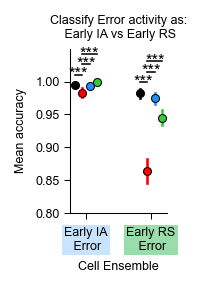

In [19]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'],ylim = [0.80,1.05], figsize = (1.25,1.90),fig_folder=5,  figure_prefix= "5C" )

In [20]:
def plot_ensemble_value_at_timebin(
    ax_plot, 
    timebin_values,
    ensemble,
    y_val,
    **kwargs):
    ''' Plot  time-bin bootstrapped metric for a given ensemble, for a given pair of classes to compare'''  

    plot_df = timebin_values.loc[timebin_values.enriched_group == ensemble,:].dropna()
    plot_df['bin_name'] = plot_df['bin_name'].str.replace(".0s to ", "-").str.replace(".0s", "").str.replace("--", "-")#rename bin
    plot_params = {'data': plot_df,  'x': 'bin_name', 'y' : y_val, 'errorbar': ('pi', 75), 'errwidth': 1.25, 'order': plot_df['bin_name'].unique(),
                  **kwargs, **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot, **plot_params,  )#make cosine sim plot itself
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)    # ax_plot.legend_.remove()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, test_name = 'cohen_d',detect_error_bar = True)
    return posthoc_df

def plot_save_time_dep_decoding(
    decoding_df,
    decoding_col,
    decoding_metric = 'mean_acc',
    decoder_comparison = None,
    ensemble = None,
    ylim = [0.825,1.04],
    figsize = (1.75,1.75),
    fig_num=5,
    figure_prefix = "5D",
    use_verbose_title = True):
    ''' main script to plot time-dependent accuracy and save values ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    fig, ax_plot = plt.subplots(1, 1, figsize = figsize, layout = 'constrained')
    
    time_decode_classes = decoding_df.loc[decoding_df[decoding_col] == decoder_comparison,:]
    posthoc_df = plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, decoding_metric, dodge = True)
    
    #for plotting titles
    decoder_comparison_clean = decoder_comparison.replace('_', ' ')
    ensemble_clean = ensemble.replace('_', ' ')
    if use_verbose_title:
        ax_title = f'{ensemble_clean} ensemble:\nClassify {verbose_titles[decoder_comparison]}'
    else:
        ax_title = f'{ensemble_clean} ensemble:\n Decoding {decoder_comparison_clean}'
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title, 'legend_false':True,'xlabel': f"Decoded time window (s)", 
    'xtick_rotation':  {'rotation':30}, 'ylabel': 'Decoding Accuracy'})
    ax_plot.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
    
    ##savefig
    fig_name = "_".join([figure_prefix, f'{ensemble_clean} ensemble time-based classification of {decoder_comparison_clean}'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=stage_to_fig[(decoder_comparison,ensemble)],  filetypes_to_save = ['png', 'svg'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_num}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc acc cohen D",txt_suffix="posthoc_text")
    return fig, ax_plot,posthoc_df 

#### Figure 5D: Time-based classification of Early IA Error vs Early RS Error, using Early RS Error ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved 5_5D_Early RS Error ensemble time-based classification of Early IA Error v Early RS Error_posthoc acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\5_5D_Early RS Error ensemble time-based classification of Early IA Error v Early RS Error_posthoc_text_01_Jul_2026.txt


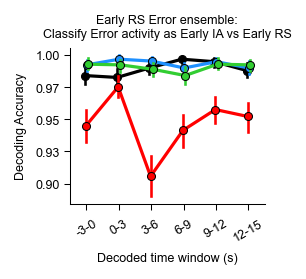

In [21]:
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col = "classes decoded", decoding_metric = 'mean_acc',
                                                 decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
    ensemble ='Early_RS_Error', figure_prefix = "5D", fig_num=5)

#### Figure 6C: Early IA/RS Correct - SVM accuracy for Early RS Error Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved 6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_01_Jul_2026.txt


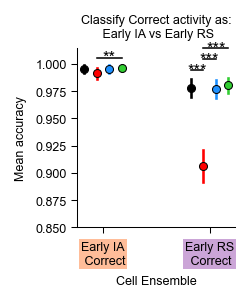

In [22]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct', 
    ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'],ylim = [0.85, 1.015], figure_prefix = "6C", fig_folder=6)

#### Figure 6D: Time-based classification of Correct as Early IA vs Early RS, using Early RS Correct ensemble data


In [23]:
time_decode_scores

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name,run_source_dataset,run_end_date,dataset_label
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.000000,-0.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.997559,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,1.000000,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,1.000000,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,1.000000,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439995,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.883789,3.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439996,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.951172,6.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439997,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.952637,9.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles
1439998,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.895020,12.0s,12,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved 6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc_text_01_Jul_2026.txt


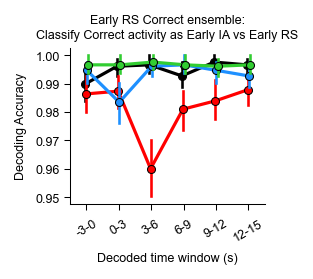

In [24]:
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col = "classes decoded", decoding_metric = 'mean_acc',
                                                 decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
    ensemble ='Early_RS_Correct', figsize = (1.75,1.75),figure_prefix = "6D", fig_num=6)

#### Figure 7C: SVM accuracy at classifying Early IA Correct vs. Late IA, using Early IA Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved 7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc_text_01_Jul_2026.txt


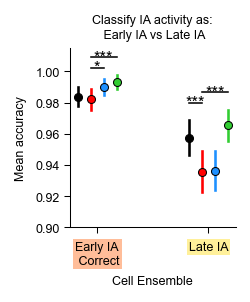

In [25]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Late_IA',
ensemble_subset = ['Early_IA_Correct', 'Late_IA'],figure_prefix = "7_C",fig_folder=7)

#### Figure 7G: SVM accuracy at classifying Early RS Correct vs. Late IA, using Early RS Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved 7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc_text_01_Jul_2026.txt


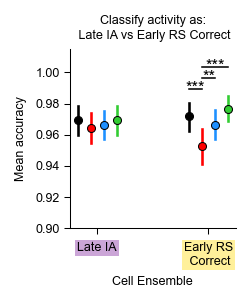

In [26]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Late_IA_v_Early_RS_Correct', 
    ensemble_subset = ['Early_RS_Correct', 'Late_IA'],figure_prefix = "7_G", fig_folder= 7)

#### Supplementary Figure 2F: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_01_Jul_2026.txt


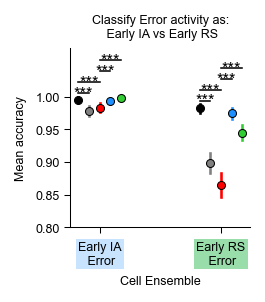

In [27]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
 ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'], ylim = [0.82,1.075], figsize = supp_svm_panel_size,
 figure_prefix = "S2_F", fig_folder= 's_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Supplementary Figure 2H: SVM accuracy classifying Correct as Early IA vs Early RS, using Early IA or RS Correct Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.
Saved s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_01_Jul_2026.txt


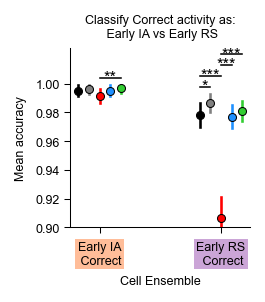

In [28]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
 ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'], ylim = [0.9,1.025], figsize = supp_svm_panel_size,
  figure_prefix = "S2_H", fig_folder='s_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Summary Figure: All SVM Classifier Accuracy Plots

Combined view of all ensemble SVM accuracy comparisons from Figures 5, 6, 7, and Supplemental Figure 2.

{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Error_v_Early_RS_Error', 'ensemble_subset': ['Early_IA_Error', 'Early_RS_Error'], 'ylim': [0.8, 1.05], 'title': '5C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Early_RS_Correct', 'ensemble_subset': ['Early_IA_Correct', 'Early_RS_Correct'], 'ylim': [0.9, 1.015], 'title': '6C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Late_IA', 'ensemble_subset': ['Early_IA_Correct', 'Late_IA'], 'ylim': [0.9, 1.015], 'title': '7C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_compa

Text(0.5, 0.98, 'Summary: SVM Classifier Accuracy by Ensemble')

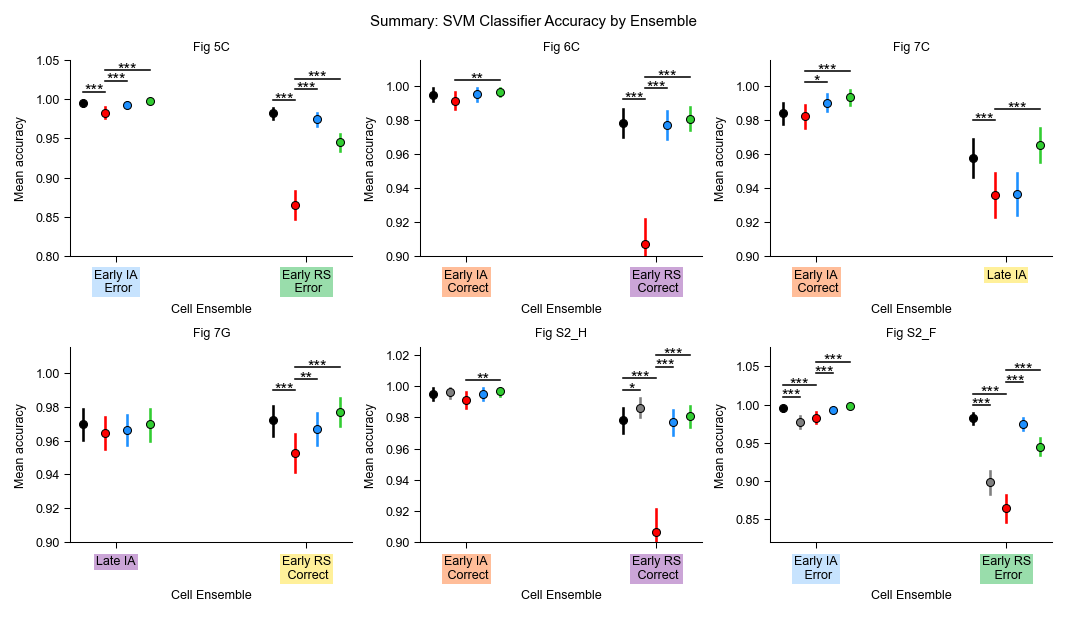

In [29]:
# Summary figure combining all SVM accuracy plots
fig, axes = plt.subplots(2, 3, figsize=(7, 4), layout="constrained")

# Define all plot configurations
plot_configs = [
    # Row 1
    {"ax": axes[0, 0], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.80, 1.05],
     "title": "5C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.015],
     "title": "6C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 2], "decoder_comparison": "Early_IA_Correct_v_Late_IA",
     "ensemble_subset": ["Early_IA_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7C", "plot_config": geno_color_dict_no_errorbar},
     # Row 2
    {"ax": axes[1, 0], "decoder_comparison": "Late_IA_v_Early_RS_Correct",
     "ensemble_subset": ["Early_RS_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7G", "plot_config": geno_color_dict_no_errorbar},
     
     #supp 
     {"ax": axes[1, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.025],
     "title": "S2_H", "plot_config": geno_order_w_WT_CLNZ_no_eb},
       {"ax": axes[1, 2], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.82, 1.075],
     "title": "S2_F", "plot_config": geno_order_w_WT_CLNZ_no_eb},
]

# Generate each subplot
for config in plot_configs:
    print(config)
    plot_decode_accuracy_ensemble_subset(
        pop_mean_decoding,
        decoding_col="classes decoded",
        decoder_comparison=config["decoder_comparison"],
        ensemble_col="enriched_group",
        ax_plot=config["ax"],
        ensemble_subset=config["ensemble_subset"],
        ylim=config["ylim"],
        plot_config=config["plot_config"]
    )
    config["ax"].set_title(f"Fig {config['title']}", )

plt.suptitle("Summary: SVM Classifier Accuracy by Ensemble",)

# # Save the summary figure
# save_fig_in_main_fig_dir(fig, fig_name="Summary_SVM_classifier_accuracy_all_comparisons", 
#                         folder_key="1", filetypes_to_save=["png", "svg"])

## Figure 3 & 4- Cross-condition generalization 

In [30]:
### CCGP plotting functions: #### 

def plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col, ax_plot):
    plot_df =  decode_out_distrib.loc[(decode_out_distrib[decoding_col] == decoder_comparison),:]
    errorbar_pi = 75
    plot_params = {'data':plot_df, 'dodge': 0.4, 'x': 'enriched_group', 'y':'accuracy','order':phase_list_IA_RS_chrono,'errorbar': ('pi', errorbar_pi), **geno_color_dict_no_errorbar}
    ## ax level changes
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params)#make cosine sim plot itself
    fig_name = f' Train: {plot_df.train_on.unique()[0]} \n Test: {plot_df.test_on.unique()[0]} \n SVM Accuracy (PI: {errorbar_pi}) ({plot_df.pseudopop_run_num.nunique()} run avg.)'
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': [0, 1.025],'xlabel': None, 'ylabel': 'Mean SVM accuracy', 'legend_false': True})#adjust plot information
    
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, test_name = 'cohen_d', detect_error_bar = False)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True, tight_offset = 0.02) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    return posthoc_df

def plot_cross_condition_generalization_performance_w_null(
    ax_plot,
    decode_out_distrib,
    decode_permuted,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ["train IA", "test RS"],
    null_percentiles = (0.05, 0.95),
    **kwargs):
    
    """Plot CCGP accuracy with null bands, only plotting posthoc stat bars
    for comparisons where at least 1 group's median exceeds the null at that ensemble.

    The returned posthoc_df additionally carries the null band for each comparison's
    two groups: group_1_null_low / group_1_null_high and group_2_null_low /
    group_2_null_high (the null_percentiles[0]/null_percentiles[1] percentiles of the
    permuted-label accuracy, default 5th/95th), plus an exceeds_null flag."""
    # Plot real data
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df = decode_out_distrib.loc[plot_mask,:]
    plot_params = {"data":plot_df, "dodge": 0.5, "errwidth": 1.5, "x": enriched_group, "y":"accuracy",
                   "order":ensembles_to_plot, "errorbar": ("pi", 75), **marker_params}
    s = sns.pointplot(ax=ax_plot, linestyles="none", **plot_params, **kwargs)
    
    # Ax decorators
    train_data, test_data = verbose_titles
    fig_name = f" {train_data.replace("_", " ")} {test_data.replace("_", " ")}"
    set_ax_title_xlabel_ylabel(ax_plot, {"title": fig_name, "ylim": ylim, "legend_false": False,
                                         "xlabel": "Cell Ensemble", "ylabel": "Cross-condition Generalization"})
    
    # Prep null data for filtering
    hue_col = marker_params["hue"]
    perm_mask = (decode_permuted[decoding_col] == decode_comp) & (decode_permuted[enriched_group].isin(ensembles_to_plot))
    null_df = decode_permuted.loc[perm_mask]
    
    # Run posthoc tests on all comparisons
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons,
                                                            detect_error_bar=True, test_name="cohen_d")
    
    # Per-ensemble null filtering: keep a posthoc row only if at least 1 group's
    # median exceeds the null 5th/95th percentile at that specific ensemble.
    # Also record each group's null band (lower/upper percentile) into posthoc_df.
    rows_to_keep = []
    null_records = []
    for idx, row in posthoc_df.iterrows():
        ensemble = row["category_compared_within"]
        exceeds_null = False
        rec = {}
        for grp_key in ["group_1", "group_2"]:
            geno = row[grp_key]
            real_vals = plot_df.loc[(plot_df[enriched_group] == ensemble) & (plot_df[hue_col] == geno), "accuracy"]
            null_vals = null_df.loc[(null_df[enriched_group] == ensemble) & (null_df[hue_col] == geno), "accuracy"]
            if len(null_vals) == 0:
                rec[f"{grp_key}_null_low"] = np.nan
                rec[f"{grp_key}_null_high"] = np.nan
                continue
            p_low = null_vals.quantile(null_percentiles[0])
            p_high = null_vals.quantile(null_percentiles[1])
            rec[f"{grp_key}_null_low"] = p_low
            rec[f"{grp_key}_null_high"] = p_high
            if len(real_vals) > 0 and (real_vals.median() > p_high or real_vals.median() < p_low):
                exceeds_null = True
        rows_to_keep.append(exceeds_null)
        null_records.append(rec)
    
    null_mask = pd.Series(rows_to_keep, index=posthoc_df.index)
    # Attach null band (lower/upper percentile of null accuracy) for each group
    posthoc_df = pd.concat([posthoc_df, pd.DataFrame(null_records, index=posthoc_df.index)], axis=1)
    posthoc_df["exceeds_null"] = null_mask
    posthoc_sig = posthoc_df.loc[null_mask & (posthoc_df["pvalue"] < 0.05)]
    print(f"Posthoc: {len(posthoc_df)} total, {null_mask.sum()} exceed null, {len(posthoc_sig)} plotted")
    if len(posthoc_sig) > 0:
        plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_sig, tight_offset=0.01, offset_constant=0.01)
    
    # Add null bands AFTER posthoc tests (avoid polluting ax.collections)
    add_null_bands(ax_plot, decode_permuted, decoding_col, decode_comp, enriched_group, ensembles_to_plot, marker_params)
    
    # More ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df

def add_null_bands(ax_plot, decode_permuted, decoding_col, decode_comp,
                   enriched_group, ensembles_to_plot, marker_params, dodge=0.5):
    """Overlay shaded bands showing 5th-95th percentile null distribution with edge lines."""
    hue_col = marker_params['hue']
    hue_order = marker_params['hue_order']
    palette = marker_params['palette']
    n_hue = len(hue_order)
    offsets = np.linspace(-dodge/2, dodge/2, n_hue)
    band_width = dodge / n_hue * 0.9

    perm_mask = (decode_permuted[decoding_col] == decode_comp) & (decode_permuted[enriched_group].isin(ensembles_to_plot))
    perm_df = decode_permuted.loc[perm_mask]

    for ens_idx, ensemble in enumerate(ensembles_to_plot):
        for hue_idx, geno in enumerate(hue_order):
            subset = perm_df.loc[(perm_df[enriched_group] == ensemble) & (perm_df[hue_col] == geno), 'accuracy']
            if len(subset) == 0:
                continue
            p5, p95 = subset.quantile(0.05), subset.quantile(0.95)
            x_center = ens_idx + offsets[hue_idx]
            x_left, x_right = x_center - band_width/2, x_center + band_width/2
            color = palette[hue_idx]
            # Shaded band: 5th-95th with edge lines
            ax_plot.fill_between(
                [x_left, x_right], p5, p95,
                color=color, alpha=0.25, zorder=0, linewidth=0)
            # ax_plot.hlines([p5, p95], x_left, x_right,colors=color, linewidths=0, linestyles='-', zorder=0.5)

### CCGP annotation functions: #### 

def add_decode_label_columns(df):
    """Add train_on, test_on, classes decoded, and total columns to a decode results DataFrame."""
    df['train_on'] = df['class_0_train'].str.cat(df['class_1_train'], sep="_").str.replace('_', ' ')
    df['test_on'] = df['class_0_test'].str.cat(df['class_1_test'], sep="_").str.replace('_', ' ')
    df['classes decoded'] = df['train_on'].str.cat(df['test_on'], sep=" v ").str.replace('_', ' ')
    df['total'] = df['true_pos'] + df['false_neg'] + df['false_pos'] + df['true_neg']
    return df


#### Load label-permuted CCGP data from run info


In [31]:
# Load label-permuted CCGP data from run info
decode_out_distrib_label_permuted = decode_dfs.get('decode_out_distrib_label_permuted')
# Apply same column transformations as for the new data
decode_out_distrib_label_permuted = add_decode_label_columns(decode_out_distrib_label_permuted)
print(f"Loaded label-permuted CCGP data: {len(decode_out_distrib_label_permuted)} rows")
print(f"Current (new) CCGP data: {len(decode_out_distrib)} rows")
decode_out_distrib_label_permuted.head(2)

Loaded label-permuted CCGP data: 1200000 rows
Current (new) CCGP data: 1200000 rows


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.519531,79.0,79.0,0.261875,0.257500,0.242500,0.238125,1.0,0.616699,0.673828,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.602051,79.0,60.0,0.303750,0.298438,0.201562,0.196250,1.0,0.478027,0.673828,...,0.25,13:30.6,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,13:30.6,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0


In [32]:
## annotate real GGCP df
decode_out_distrib = add_decode_label_columns(decode_out_distrib)
decode_out_distrib.head(2)

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,training_label_permuted,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.674805,79.0,79.00,0.464063,0.210625,0.289375,0.035938,0.0,0.615234,0.663086,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.694824,79.0,61.75,0.423125,0.271875,0.228125,0.076875,0.0,0.489990,0.663086,...,0.25,49:14.4,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,49:14.4,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0


#### Figure 3B - CCGP + null for models train IA, test RS

In [33]:
#function- ax level plot of CCGP
from ax_modifier_functions import add_xtick_color_boxes
def plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ['train IA', 'test RS'],
    **kwargs):
    """    Plots cross-condition generalization SVM accuracy and performs post-hoc tests.
    Parameters:
    - decode_out_distrib: pd.DataFrame, decoding results
    - decoding_col: str, column name to compare with decode_comp
    - decode_comp: value to filter decoding_col on
    - enriched_group: str, column name used to group for plotting
    - ensembles_to_plot: list of group names to include in the plot
    - geno_color_dict_no_errorbar: dict, seaborn styling arguments like hue/colors
    - preset_comparison_list: list of tuples, preset comparisons for posthoc tests
    - ax_plot: matplotlib.axes.Axes, axis to plot on
    Returns:    - ax_plot with the plot drawn and significance bars added
    """
    ## plot info 
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df =  decode_out_distrib.loc[plot_mask,:]
    plot_params = {'data':plot_df, 'dodge': 0.5,'errwidth': 1.5, 'x': 'enriched_group', 'y':'accuracy','order':ensembles_to_plot, 'errorbar': ('pi', 75), **marker_params}
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params,**kwargs)#make cosine sim plot itself
    ## ax level changes
    train_data, test_data = verbose_titles#new- extract cleaner string title from train/test data
    fig_name = f" {train_data.replace('_', ' ') }\n {test_data.replace('_', ' ')}"
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': f"Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})#adjust plot information
    #posthoc difference detection
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant = 0.015) 
    #more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df

In [34]:
#create longer titles for figures + combine into dict for substitution into figures
verbose_dicts = { 'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'], 
                 'train_Early_IA_Correct_Early_RS_Correct':['Classify IA vs. RS:','Train on Correct trials, Test on Errors']}

Posthoc: 12 total, 11 exceed null, 8 plotted
Saved 3_null_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _ccgp_all_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_null_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _ccgp_posthoc_results_text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


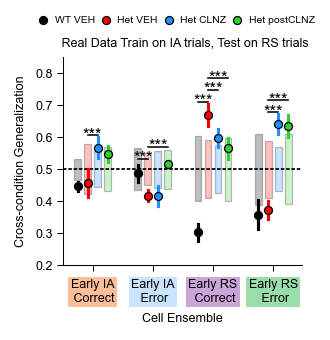

In [35]:
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
# Figure 3B: Train on IA, Test on RS
train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_3b = plot_cross_condition_generalization_performance_w_null(ax_plot, decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", 
    decode_comp=decode_comp_3b,
    enriched_group="enriched_group", 
    ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, 
    marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85],
      verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1)
add_xtick_color_boxes(ax_plot, ensembles_3b, stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_name = f"null_CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ "
save_plot_record_as_csv_txt(posthoc_df_3b,"3",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png','svg'])

#### Figure 4B- CCG + null: for models train Correct (IA/RS) | test Error (IA/RS)

Posthoc: 12 total, 11 exceed null, 10 plotted
Saved 4_null CCGP (early ens) train_correct_test_error_ccgp_all_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_null CCGP (early ens) train_correct_test_error_ccgp_posthoc_results_text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


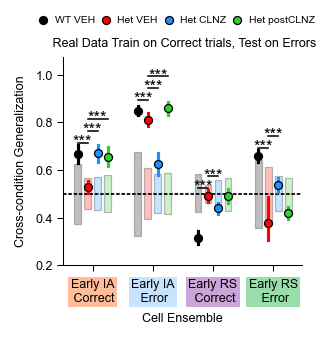

In [36]:
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')

# Figure 4B: Train on Correct, Test on Error
train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_4b = plot_cross_condition_generalization_performance_w_null(ax_plot, decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", decode_comp=decode_comp_4b,
    enriched_group="enriched_group", ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.075], verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(ax_plot, ensembles_4b, stage_palette_dict)

##ax modifiers
hand, labs =ax_plot.get_legend_handles_labels() 
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )
##save fig_posthoc 
fig_name = f"null CCGP (early ens) train_correct_test_error"
save_plot_record_as_csv_txt(posthoc_df_4b,"4",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=4, filetypes_to_save = ['png','svg'])

In [37]:
#cols to keep
confusion_mat_cols = ['true_pos','false_neg', 'false_pos', 'true_neg']
class_list = ['class_0_train','class_1_train','class_0_test','class_1_test']
run_ID_cols = ['geno_day','accuracy','pseudopop_run_num']



In [38]:
def transform_confusion_cols(decoding_results = pd.DataFrame,
                             confusion_mat_cols = confusion_mat_cols,
                             run_ID_cols = run_ID_cols,
                             class_list = class_list):
    df = decoding_results.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].rename({'enriched_group':'ensemble'},axis = 1)
    df[class_list] = df[class_list].astype(str)

    # 3. Build all new columns w. vectorized string operations
    df = df.assign(
        train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
        test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
        Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
        Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
        Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
        Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
    )
    confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
                    'Predict_class_0_train_x_Actual_class_1_test',
                    'Predict_class_1_train_x_Actual_class_0_test', 
                    'Predict_class_0_train_x_Actual_class_0_test']
    # 4. reset index and melt
    grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])
    df= grouped.reset_index().melt(value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'], 
                                id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names)

    # 5. Define the mapping from your “variable” names to the Predict_… columns
    col_map = {'true_pos':  'Predict_class_1_train_x_Actual_class_1_test',
               'false_neg': 'Predict_class_0_train_x_Actual_class_1_test',
               'false_pos': 'Predict_class_1_train_x_Actual_class_0_test',
               'true_neg':  'Predict_class_0_train_x_Actual_class_0_test'}
    
    df['var_column'] = df['variable'].map(col_map) #name of column containing var info
    df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
    df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
    rename_df = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']].set_index(("train_on")).copy()
    rename_df.loc[:,'actual'] = rename_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    rename_df['value'] = rename_df['value']*2
    return rename_df 

In [39]:
CCGP_prediction_df = transform_confusion_cols(decoding_results=decode_out_distrib, confusion_mat_cols = confusion_mat_cols, run_ID_cols = run_ID_cols, class_list = class_list)
CCGP_prediction_df.tail(3)

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.566406,9999,0.97,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Late_RS,WT VEH,0.500000,9999,1.00,Predict_Early_IA_Correct_x_Actual_Early_RS_Cor...,Predict_Early_IA_Correct,Early RS Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT VEH,0.485107,9999,0.97,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [40]:
def plot_ccg_confusion_single_proportion(ax,
                                         proportion_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ('pi', 95),
                                         ylim=[0, 0.515],
                                         title_type = {'train_Early_IA_Correct_x_Early_RS_Correct':'Classification (IA vs. RS) of',
                                                       'train_Early_IA_Correct_x_Early_IA_Error': 'Classification (correct vs. error) of'},
                                         **kwargs):
    ''' started 6/25/25- To plot distributions of ccg''' 
    #modify df for better plot
    proportion_df = proportion_df.loc[train,:].reset_index()
    plot_df = proportion_df.loc[proportion_df.ensemble == ens,:].copy()
    plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    #given you plot only one type, filter by type
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df['value'] = plot_df['value'] *100 #multiply by 100 to return percent
    stage_order = sorted(set(plot_df.loc[:,'actual']))
    plot_params = dict(data = plot_df,ax = ax,x = 'actual', y = 'value', dodge = 0.5, linestyles = 'none',order = stage_order,errorbar = errorbar, 
                       **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot])
    s = sns.pointplot(**plot_params)
    ###modify ax decorators
    set_pointplot_edgecolor(ax)
    ax_title = f"{title_type[train]}\n activity in {ens.replace('_', ' ')} ensemble"
    ylabel_options = {'train_Early_IA_Correct_x_Early_IA_Error': 'Correct',
                      'train_Early_IA_Correct_x_Early_RS_Correct':'RS'}
    set_labels(ax, label_dict = {'title':ax_title,
                                 'legend_false':True, 
                                 'xlabel':f"Test Data Stage",
                                 'ylim':ylim, 'ylabel': f"% Classified as {ylabel_options[train]}"})
    #run posthoc test 
    if "WT CLNZ" in plot_params['hue_order']: #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    # Draw canvas to ensure error bar coordinates are computed (fixes multi-subplot issue)
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.0175,offset_constant = 0.0085) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) 
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

## NEW- Null band w. label-permut 

Posthoc: 12 total, 11 exceed null, 8 plotted
Posthoc: 12 total, 11 exceed null, 10 plotted
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


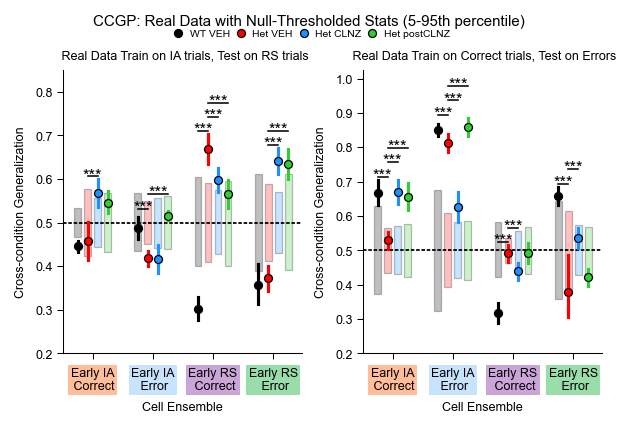

In [41]:
# --- CCGP: Real data with null-thresholded posthoc stats ---
fig, axes = plt.subplots(1, 2, figsize=(4, 2.5), layout="constrained")

# Figure 3B: Train on IA, Test on RS
train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_3b = plot_cross_condition_generalization_performance_w_null(
    axes[0], decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", decode_comp=decode_comp_3b,
    enriched_group="enriched_group", ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)

# Figure 4B: Train on Correct, Test on Error
train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_df_4b = plot_cross_condition_generalization_performance_w_null(
    axes[1], decode_out_distrib, decode_out_distrib_label_permuted,
    decoding_col="classes decoded", decode_comp=decode_comp_4b,
    enriched_group="enriched_group", ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=["Real Data", verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Clean up legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()
hand, labs = axes[0].get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc="lower center", ncols=4, frameon=False)
fig.suptitle("CCGP: Real Data with Null-Thresholded Stats (5-95th percentile)", y=1.08)

## save fig:
combined_fig_name = "CCG_Real_vs_LabelPermuted_Overlay_NullThresholded"
save_fig_in_main_fig_dir(fig, fig_name=combined_fig_name, folder_key="r_1", filetypes_to_save=["png", "svg"])


#### Figure 3C + Null: CCG model classifications of activity of Early RS Correct ensemble 

In [42]:
def add_null_bands_confusion(ax, null_proportion_df, train, ens, prediction_class,
                             genos_to_plot=geno_order, dodge=0.5):
    """Overlay shaded 5th-95th percentile null bands on a ccg confusion proportion plot."""
    marker_params = {True: geno_order_w_WT_CLNZ_no_eb, False: geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot]
    hue_col = marker_params['hue']
    hue_order = marker_params['hue_order']
    palette = marker_params['palette']
    n_hue = len(hue_order)
    offsets = np.linspace(-dodge / 2, dodge / 2, n_hue)
    band_width = dodge / n_hue * 0.9

    # Filter null data the same way plot_ccg_confusion_single_proportion does
    plot_df = null_proportion_df.loc[train, :].reset_index()
    plot_df = plot_df.loc[(plot_df.ensemble == ens) & (plot_df.predict == prediction_class)]
    plot_df['value'] = plot_df['value'] * 100
    stage_order = sorted(set(plot_df['actual']))

    for stage_idx, stage in enumerate(stage_order):
        for hue_idx, geno in enumerate(hue_order):
            subset = plot_df.loc[(plot_df['actual'] == stage) & (plot_df[hue_col] == geno), 'value']
            if len(subset) == 0:
                continue
            p5, p95 = subset.quantile(0.05), subset.quantile(0.95)
            x_center = stage_idx + offsets[hue_idx]
            x_left, x_right = x_center - band_width / 2, x_center + band_width / 2
            color = palette[hue_idx]
            ax.fill_between([x_left, x_right], p5, p95,
                            color=color, alpha=0.25, zorder=0, linewidth=0)

def plot_ccg_confusion_single_proportion_w_null(ax,
                                         proportion_df,
                                         null_proportion_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ("pi", 95),
                                         ylim=[0, 0.515],
                                         title_type = {"train_Early_IA_Correct_x_Early_RS_Correct":"Classification (IA vs. RS) of \n",
                                                       "train_Early_IA_Correct_x_Early_IA_Error": "Classification (correct vs. error) of \n"},
                                         null_percentiles = (0.05, 0.95),
                                         **kwargs):
    """Plot ccg confusion proportions with null bands, only running posthoc stats
    for comparisons where at least 1 group's median exceeds the null distribution at that stage."""
    # Filter and prep real data
    proportion_df = proportion_df.loc[train,:].reset_index()
    plot_df = proportion_df.loc[proportion_df.ensemble == ens,:].copy()
    plot_df.loc[:,"actual"] = plot_df.loc[:,"actual"].str.removeprefix("Actual_").str.replace("_", " ")
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df["value"] = plot_df["value"] * 100
    stage_order = sorted(set(plot_df.loc[:,"actual"]))
    
    marker_params = {True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot]
    plot_params = dict(data=plot_df, ax=ax, x="actual", y="value", dodge=0.5,
                       linestyles="none", order=stage_order, errorbar=errorbar, **marker_params)
    s = sns.pointplot(**plot_params)
    set_pointplot_edgecolor(ax)
    
    # Ax decorators
    ax_title = f"{title_type[train]} activity in {ens.replace("_", " ")} ensemble"
    ylabel_options = {"train_Early_IA_Correct_x_Early_IA_Error": "Correct",
                      "train_Early_IA_Correct_x_Early_RS_Correct": "RS"}
    set_labels(ax, label_dict={"title": ax_title, "legend_false": True,
                               "xlabel": "Test Data Stage", "ylim": ylim,
                               "ylabel": f"% Classified as {ylabel_options[train]}"})
    
    # Prep null data for filtering
    hue_col = marker_params["hue"]
    null_df = null_proportion_df.loc[train,:].reset_index()
    null_df = null_df.loc[(null_df.ensemble == ens) & (null_df.predict == prediction_class)]
    null_df["value"] = null_df["value"] * 100
    
    if "WT CLNZ" in marker_params["hue_order"]:
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    
    # Run posthoc tests on all comparisons
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons,
                                                            detect_error_bar=True, test_name="cohen_d")
    
    # Per-stage null filtering: keep a posthoc row only if at least 1 group's
    # median exceeds the null 5th/95th percentile at that specific stage
    rows_to_keep = []
    for idx, row in posthoc_df.iterrows():
        stage = row["category_compared_within"]
        exceeds_null = False
        for geno in [row["group_1"], row["group_2"]]:
            real_vals = plot_df.loc[(plot_df["actual"] == stage) & (plot_df[hue_col] == geno), "value"]
            null_vals = null_df.loc[(null_df["actual"] == stage) & (null_df[hue_col] == geno), "value"]
            if len(real_vals) == 0 or len(null_vals) == 0:
                continue
            p_low = null_vals.quantile(null_percentiles[0])
            p_high = null_vals.quantile(null_percentiles[1])
            if real_vals.median() > p_high or real_vals.median() < p_low:
                exceeds_null = True
                break
        rows_to_keep.append(exceeds_null)
    
    null_mask = pd.Series(rows_to_keep, index=posthoc_df.index)
    posthoc_sig = posthoc_df.loc[null_mask & (posthoc_df["pvalue"] < 0.05)]
    print(f"Posthoc: {len(posthoc_df)} total, {null_mask.sum()} exceed null, {len(posthoc_sig)} plotted")
    if len(posthoc_sig) > 0:
        plot_sig_bars_w_comp_df_tight(ax, posthoc_sig,
                                      tight_offset=0.0175, offset_constant=0.0085)
    
    # Add null bands AFTER posthoc tests (avoid polluting ax.collections)
    add_null_bands_confusion(ax, null_proportion_df, train, ens, prediction_class,
                             genos_to_plot=genos_to_plot)
    
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

In [43]:
null_CCG_prediction = transform_confusion_cols(decoding_results=decode_out_distrib_label_permuted, confusion_mat_cols = confusion_mat_cols, run_ID_cols = run_ID_cols, class_list = class_list)
null_CCG_prediction.head()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.519531,0,0.523750,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.602051,0,0.607500,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.491699,0,0.388125,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.494629,0,0.457500,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.530273,0,0.551250,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos


Posthoc: 6 total, 5 exceed null, 5 plotted
Saved 3_null_CCG uni-class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_null_CCG uni-class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


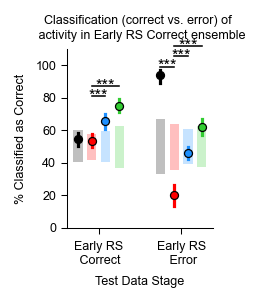

In [44]:
##Figure 3C- TRAIN IA
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
# combine null + proportion predicted plot
plot_config = {"ensemble": "Early_RS_Correct", "train": "train_Early_IA_Correct_x_Early_IA_Error","prediction_class": "Predict_Early_IA_Correct", "title_label": "3C"}
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax, 
                                                         proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                          train= plot_config["train"],
                                                          ens= plot_config["ensemble"],
                                                          prediction_class=plot_config["prediction_class"],
                                                          genos_to_plot=geno_order,
                                                          errorbar=('pi', 75),
                                                          ylim=[0, 110])

##savefig 
fig_num = 3
fig_name = f"null_CCG uni-class pred- Train IA test RS - {plot_config['ensemble']} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4C + Null: % samples classified as RS, for activity from Early IA Correct ensemble

Posthoc: 6 total, 3 exceed null, 3 plotted
Saved 4_null_ CCG uni-class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_null_ CCG uni-class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


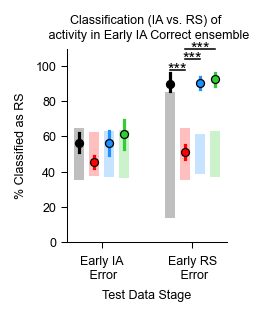

In [45]:

fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
# combine null + proportion predicted plot
plot_config = {"ensemble": "Early_IA_Correct", "train": "train_Early_IA_Correct_x_Early_RS_Correct", "prediction_class": "Predict_Early_RS_Correct", "title_label": "4C"}
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax, 
                                                         proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                          train= plot_config["train"],
                                                          ens= plot_config["ensemble"],
                                                          prediction_class=plot_config["prediction_class"],
                                                          genos_to_plot=geno_order,
                                                          errorbar=('pi', 75),
                                                          ylim=[0, 110])
# ##savefig 
fig_num = 4
fig_name = f"null_ CCG uni-class pred- Train Correct test Error- {plot_config['ensemble']} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None,
                        csv_suffix="predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4F + Null: % of samples classified as RS, for activity from Early RS Error ensemble

Posthoc: 6 total, 5 exceed null, 4 plotted
Saved 4_null_CCG uni-class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_null_CCG uni-class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


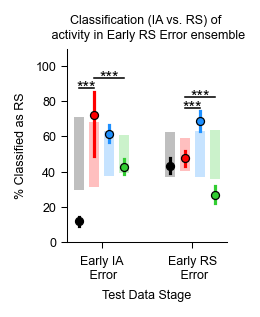

In [46]:
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')

# combine null + proportion predicted plot
plot_config = {"ensemble": "Early_RS_Error", "train": "train_Early_IA_Correct_x_Early_RS_Correct", "prediction_class": "Predict_Early_RS_Correct", "title_label": "4F"}
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax, 
                                                         proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                          train= plot_config["train"],
                                                          ens= plot_config["ensemble"],
                                                          prediction_class=plot_config["prediction_class"],
                                                          genos_to_plot=geno_order,
                                                          errorbar=('pi', 75),
                                                          ylim=[0, 110])
##savefig 
fig_num = 4
fig_name = f"null_CCG uni-class pred- Train Correct test Error- {plot_config['ensemble']} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix="predict_posthoc cohen d",txt_suffix="predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### supplement uniproportion CCG classes

Posthoc: 8 total, 7 exceed null, 7 plotted
Saved 4_s_supp_CCG+null single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_supp_CCG+null single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


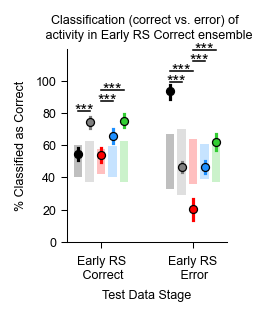

In [47]:
## SUPP v Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
plot_config = {"ensemble": "Early_RS_Correct", "train": "train_Early_IA_Correct_x_Early_IA_Error","prediction_class": "Predict_Early_IA_Correct", "title_label": "3C"}

fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax, 
                                                         proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                          train= plot_config["train"],
                                                          ens= plot_config["ensemble"],
                                                          prediction_class=plot_config["prediction_class"],
                                                          genos_to_plot = geno_order_w_WT_CLNZ,
                                                          errorbar = ('pi', 75), ylim=[0, 120],)
##savefig 
fig_name = f"supp_CCG+null single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"4_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix=f"supp_predict_posthoc cohen d",txt_suffix=f"supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_4", filetypes_to_save = ['png','svg'])

Posthoc: 8 total, 7 exceed null, 6 plotted
Saved 4_s_supp_CCG + null 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_supp_CCG + null 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


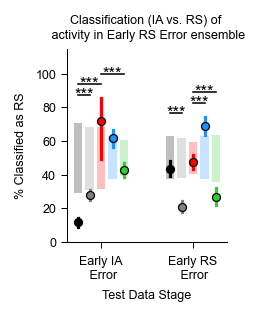

In [48]:
#SUPP FIGURE 4F
plot_config = {"ensemble": "Early_RS_Error", "train": "train_Early_IA_Correct_x_Early_RS_Correct", "prediction_class": "Predict_Early_RS_Correct", "title_label": "4F"}
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax,  proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                  train = plot_config["train"],
                                                  ens= plot_config["ensemble"],
                                                  genos_to_plot = geno_order_w_WT_CLNZ,
                                                  prediction_class= plot_config["prediction_class"],
                                                  errorbar = ('pi', 75),ylim=[0, 115])
##savefig 
fig_num = 4
fig_name = f"supp_CCG + null 1_class pred-Train_Correct_Test_Error- {plot_config['ensemble']} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"4_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_4', filetypes_to_save = ['png','svg'])

Posthoc: 8 total, 5 exceed null, 5 plotted
Saved 4_s_supp_CCG + null 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_supp_CCG + null 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


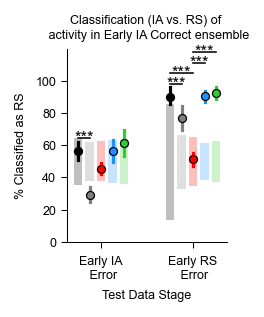

In [49]:
#SUPP FIGURE 4- IA Correct
plot_config = {"ensemble": "Early_IA_Correct", "train": "train_Early_IA_Correct_x_Early_RS_Correct", "prediction_class": "Predict_Early_RS_Correct", "title_label": "4C"}
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax,  proportion_df = CCGP_prediction_df,
                                                          null_proportion_df = null_CCG_prediction,
                                                  train = plot_config["train"],
                                                  ens= plot_config["ensemble"],
                                                  genos_to_plot = geno_order_w_WT_CLNZ,
                                                  prediction_class= plot_config["prediction_class"],
                                       errorbar = ('pi', 75), ylim=[0, 120])
##savefig 
fig_num = 4
fig_name = f"supp_CCG + null 1_class pred-Train_Correct_Test_Error-{plot_config['ensemble']} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"4_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_4', filetypes_to_save = ['png','svg'])

#### Combined CCG Predictions + Null: 3C, 4C & F

Posthoc: 6 total, 5 exceed null, 5 plotted
Posthoc: 6 total, 3 exceed null, 3 plotted
Posthoc: 6 total, 5 exceed null, 4 plotted
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


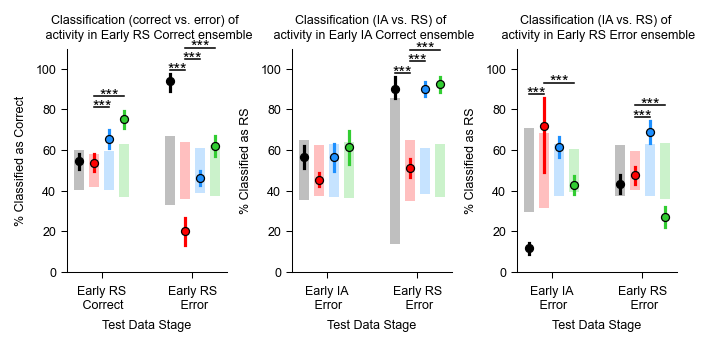

In [50]:
## Combined CCG Predictions + Null: 3C, 4C, 4F
plot_configs = [
    {"ensemble": "Early_RS_Correct",
     "train": "train_Early_IA_Correct_x_Early_IA_Error",
     "prediction_class": "Predict_Early_IA_Correct",
     "title_label": "3C"},
    {"ensemble": "Early_IA_Correct",
     "train": "train_Early_IA_Correct_x_Early_RS_Correct",
     "prediction_class": "Predict_Early_RS_Correct",
     "title_label": "4C"},
    {"ensemble": "Early_RS_Error",
     "train": "train_Early_IA_Correct_x_Early_RS_Correct",
     "prediction_class": "Predict_Early_RS_Correct",
     "title_label": "4F"},
]

fig, axes = plt.subplots(1, 3, figsize=(ccg_uniprop_figsize[0] * 3, 1.1* ccg_uniprop_figsize[1]), layout="constrained")

for ax, config in zip(axes, plot_configs):
    plot_ccg_confusion_single_proportion_w_null(ax, CCGP_prediction_df, null_CCG_prediction,
                                         train=config["train"],
                                         ens=config["ensemble"],
                                         prediction_class=config["prediction_class"],
                                         genos_to_plot=geno_order,
                                         errorbar=('pi', 75),
                                         ylim=[0, 110])

## savefig
fig_name = "Combined CCG single class pred + Null - 3C 4C 4F"
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key="s_4", filetypes_to_save=["png", "svg"])


## Revision requests:


#### Import revision specific datasets:

In [51]:
## choose run record to draw 
run_record_loc = r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_25_Mar_2026'
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
last_run_info = pd.read_csv(run_record_loc + '/' + generalize_svm_record_file)
last_run_info

,Unnamed: 0,run_date,decoding_type,data_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,0,25_Mar_2026,out_of_distribution_whole_pop,post_outcome_activity,2026-03-25 21:40:37.037785,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
1,1,25_Mar_2026,out_of_distribution_whole_pop_permuted,post_outcome_activity,2026-03-25 21:40:37.038783,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,NaN
2,2,25_Mar_2026,out_of_distribution_activity_match,post_outcome_activity,2026-03-25 21:40:37.039785,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,NaN


In [52]:
last_run_info['run_datetime'] = last_run_info.apply(parse_run_datetime, axis=1)
latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_datetime'].idxmax()]
print(f"run_dataset_used in loaded runs: {latest_runs['run_dataset_used'].unique()}")
latest_runs

run_dataset_used in loaded runs: ['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet']


,Unnamed: 0,run_date,decoding_type,data_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved,run_datetime
2,2,25_Mar_2026,out_of_distribution_activity_match,post_outcome_activity,2026-03-25 21:40:37.039785,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,NaN,2026-03-25 21:40:37.039785
0,0,25_Mar_2026,out_of_distribution_whole_pop,post_outcome_activity,2026-03-25 21:40:37.037785,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25 21:40:37.037785
1,1,25_Mar_2026,out_of_distribution_whole_pop_permuted,post_outcome_activity,2026-03-25 21:40:37.038783,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,NaN,2026-03-25 21:40:37.038783


In [53]:
decode_dfs = get_matrix_of_run_record(latest_runs, decoding_type_to_var, col_to_extract= 'run_output_filename')


extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_25_Mar_2026\Decode (Activity Match CCGP) 1000 iter post_outcome_activity 25_Mar_2026.parquet
Loaded out_of_distribution_activity_match from 2026-03-25 21:40:37.039785 (120000 rows) -> decode_CCG_activity_match
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_25_Mar_2026\Decode (Out of Distrib Whole Pop) 1000 pseudopop post_outcome_activity 25_Mar_2026.parquet
Loaded out_of_distribution_whole_pop from 2026-03-25 21:40:37.037785 (20000 rows) -> decode_out_distrib_whole_pop
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_25_Mar_2026\Decode (PERMUTE

#### Activity match cell pops

In [54]:
decode_activity_match = decode_dfs.get("decode_CCG_activity_match")
# Apply same column transformations as for the new data
decode_activity_match = add_decode_label_columns(decode_activity_match)
decode_activity_match.head(2)

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,n_match_ids_in_train,n_ens_test_ids_in_both_class_0_1,n_match_ids_in_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.431885,109.0,109.00,0.228750,0.203125,0.296875,0.271250,109.0,109.0,109.0,...,0.25,2026-03-25 21:40:37.039785,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.545410,79.0,60.75,0.284375,0.260938,0.239063,0.215625,79.0,79.0,79.0,...,0.25,2026-03-25 21:40:37.039785,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0


In [55]:
activity_match_CCGP_df = transform_confusion_cols(
    decoding_results=decode_activity_match,
    confusion_mat_cols=confusion_mat_cols,
    run_ID_cols=run_ID_cols,
    class_list=class_list
)
activity_match_CCGP_df.head(2)

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.431885,0,0.45750,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.545410,0,0.56875,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos


Posthoc: 12 total, 9 exceed null, 7 plotted
Saved 4_s_activity_match_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _ccgp_all_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_activity_match_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ _ccgp_posthoc_results_text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


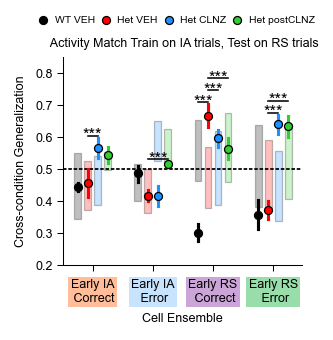

In [56]:
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
# Figure 3B: Train on IA, Test on RS
train_data = "train_Early_IA_Correct_Early_IA_Error"
decode_comp_3b = "Early IA Correct Early IA Error v Early RS Correct Early RS Error"
ensembles_3b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_3b_activityMatch = plot_cross_condition_generalization_performance_w_null(ax_plot, decode_out_distrib, decode_activity_match,
    decoding_col="classes decoded", 
    decode_comp=decode_comp_3b,
    enriched_group="enriched_group", 
    ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, 
    marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85],
      verbose_titles=["Activity Match", verbose_dicts[train_data][1]], scale=1)
add_xtick_color_boxes(ax_plot, ensembles_3b, stage_palette_dict)

hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_num = 's_4'
fig_name = f"activity_match_CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ "
save_plot_record_as_csv_txt(posthoc_3b_activityMatch,"4_s",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['pdf', 'png','svg'])

Posthoc: 12 total, 12 exceed null, 10 plotted
Saved 4_s_activity_match_CCGP- Train on Correct trials, Test on Errors_Early stage ens_ _ccgp_all_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_activity_match_CCGP- Train on Correct trials, Test on Errors_Early stage ens_ _ccgp_posthoc_results_text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


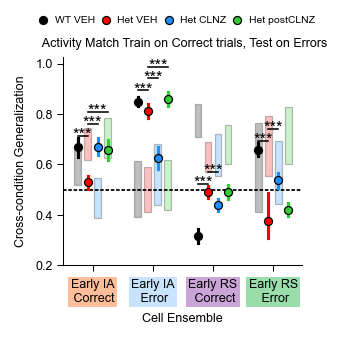

In [65]:
# Supplementary (Activity Match) Figure 4B: Train on Correct, Test on Error
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')

# Figure 4B: Train on Correct, Test on Error
train_data = "train_Early_IA_Correct_Early_RS_Correct"
decode_comp_4b = "Early IA Correct Early RS Correct v Early IA Error Early RS Error"
ensembles_4b = ["Early_IA_Correct", "Early_IA_Error", "Early_RS_Correct", "Early_RS_Error"]

posthoc_4b_activityMatch = plot_cross_condition_generalization_performance_w_null(ax_plot, decode_out_distrib, decode_activity_match,
    decoding_col="classes decoded", 
    decode_comp=decode_comp_4b,
    enriched_group="enriched_group", 
    ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, 
    marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025],
      verbose_titles=["Activity Match", verbose_dicts[train_data][1]], scale=1)
add_xtick_color_boxes(ax_plot, ensembles_4b, stage_palette_dict)

hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_num = 's_4'
fig_name = f"activity_match_CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ "
save_plot_record_as_csv_txt(posthoc_4b_activityMatch,"4_s",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['pdf', 'png','svg'])


#### Setup All cell pop. decoding:

In [58]:
## import whole population (ens member only) & label permuted counterpart
whole_pop_decode = decode_dfs.get('decode_out_distrib_whole_pop')
# Apply same column transformations as for the new data
whole_pop_decode = add_decode_label_columns(whole_pop_decode)
whole_pop_decode.head(2)


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,shuffle_labels,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.596250,624.0,397.25,0.440312,0.155938,0.344063,0.059687,0.0,0.446491,0.43656,...,0.25,2026-03-25 21:40:37.037785,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.530938,624.0,439.25,0.424687,0.106250,0.393750,0.075313,0.0,0.438115,0.43656,...,0.25,2026-03-25 21:40:37.037785,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0


In [59]:
## import whole population label permuted null df
whole_pop_decode_permuted = decode_dfs.get('decode_out_distrib_whole_pop_permuted')
## transform all cell permutation test
whole_pop_decode_permuted = add_decode_label_columns(whole_pop_decode_permuted)
whole_pop_decode_permuted.head(2)

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,shuffle_labels,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,...,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,run_source_dataset,run_end_date,dataset_label,classes decoded,total
0,0.511250,624.0,399.5,0.211563,0.299687,0.200313,0.288438,1.0,0.980384,0.508173,...,0.25,2026-03-25 21:40:37.038783,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.491875,624.0,439.0,0.243125,0.248750,0.251250,0.256875,1.0,0.979107,0.515767,...,0.25,2026-03-25 21:40:37.038783,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-03-25,New Ensembles,Early IA Error Early RS Error v Early IA Corre...,1.0


In [60]:
## Transform whole_pop decoding results into CCGP prediction format
whole_pop_CCGP_prediction_df = transform_confusion_cols(decoding_results=whole_pop_decode, confusion_mat_cols=confusion_mat_cols, run_ID_cols=run_ID_cols,class_list=class_list)
whole_pop_CCGP_prediction_df.head()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,whole_pop,Het CLNZ,0.596250,0,0.880625,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,whole_pop,Het CLNZ,0.530938,0,0.849375,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,whole_pop,Het CLNZ,0.573125,0,0.435000,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,whole_pop,Het CLNZ,0.570625,0,0.490000,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,whole_pop,Het VEH,0.707813,0,0.594375,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos


In [61]:
## Transform NULL whole_pop decoding results into CCGP prediction format
null_whole_pop_CCGP_df = transform_confusion_cols(decoding_results=whole_pop_decode_permuted, confusion_mat_cols=confusion_mat_cols,run_ID_cols=run_ID_cols,class_list=class_list)
null_whole_pop_CCGP_df.head()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,whole_pop,Het CLNZ,0.511250,0,0.423125,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,whole_pop,Het CLNZ,0.491875,0,0.486250,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,whole_pop,Het CLNZ,0.454688,0,0.392500,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,whole_pop,Het CLNZ,0.478750,0,0.461875,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,whole_pop,Het VEH,0.541562,0,0.675000,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos


#### CCGP- all cells: predicted stages of activity

Posthoc: 6 total, 6 exceed null, 5 plotted
Saved 4_s_CCG single class pred- Train IA test RS - whole_pop ensemble_predict_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_s_CCG single class pred- Train IA test RS - whole_pop ensemble_predict_posthoc cohen d text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


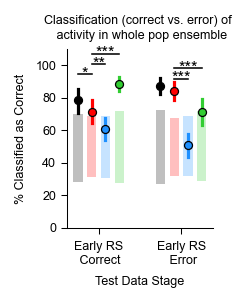

In [62]:
## whole_pop - TRAIN IA
ensemble = "whole_pop"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
posthoc_df = plot_ccg_confusion_single_proportion_w_null(ax, whole_pop_CCGP_prediction_df,null_whole_pop_CCGP_df,
                                                  train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order,
                                                  prediction_class= "Predict_Early_IA_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)
##savefig
fig_num = "s_4"
fig_name = f"CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,"4_s",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### CCGP: whole population ensemble - Train Correct (IA/RS), Test Error (IA/RS)

Posthoc: 3 total, 3 exceed null, 3 plotted
Saved s_4_SVM generalize (whole_pop ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_01_Jul_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_4_SVM generalize (whole_pop ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_01_Jul_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_4\01_Jul_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\01_Jul_2026' already exists.


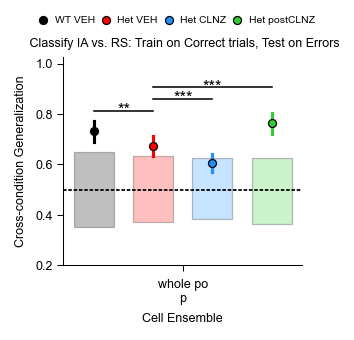

In [63]:
## Figure 4B equivalent - whole_pop ensemble: Train Correct, Test Error
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
posthoc_df = plot_cross_condition_generalization_performance_w_null(ax_plot, whole_pop_decode,whole_pop_decode_permuted,
    decoding_col = 'classes decoded',
    decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error',
    enriched_group = 'enriched_group',
    ensembles_to_plot = ['whole_pop'],
    posthoc_comparisons= preset_comparison_list,
    marker_params= geno_color_dict_no_errorbar,
    verbose_titles= verbose_dicts[train_data], scale = 1.)
##ax modifiers
hand, labs = ax_plot.get_legend_handles_labels()
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0), loc = 'lower center', ncols = 4, frameon = False, title = None)
##save fig_posthoc
fig_name = f"SVM generalize (whole_pop ens) train_correct_test_error accuracy"
fig_num = "s_4"
save_plot_record_as_csv_txt(posthoc_df, fig_num, fig_name, csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d", txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])